In [1]:
!git clone https://github.com/Tahoni01/Continual-hate-speech-detection.git
%cd Continual-hate-speech-detection
!ls

Cloning into 'Continual-hate-speech-detection'...
remote: Enumerating objects: 196, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 196 (delta 27), reused 5 (delta 5), pack-reused 148 (from 1)
Receiving objects: 100% (196/196), 303.22 KiB | 9.78 MiB/s, done.
Resolving deltas: 100% (70/70), done.
/content/Continual-hate-speech-detection
dataset     models	    README.md	      src	utils
Main.ipynb  old_main.ipynb  requirements.txt  strategy


In [2]:
import torch
from dataset.df_loader import (getdf_davidson, getdf_hatexplain)
from dataset.stream_generator import (create_continual_stream, online_stream)
from transformers import (AutoTokenizer, AutoConfig)
from models.model_builder import CustomClassifier
from models.trainer import ContinualTrainer

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", device)

DEVICE: cuda


In [4]:
print("Loading datasets...")

df_dv = getdf_davidson()
df_hx = getdf_hatexplain()

print("Davidson:", df_dv.shape)
print("HateXplain:", df_hx.shape)

Loading datasets...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.63M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/24783 [00:00<?, ? examples/s]

                                                text      label    source
0  rt as a woman you shouldnt complain about clea...     normal  davidson
1  rt boy dats coldtyga dwn bad for cuffin dat ho...  offensive  davidson
2  rt dawg rt you ever fuck a bitch and she start...  offensive  davidson
3                          rt she look like a tranny  offensive  davidson
4  rt the shit you hear about me might be true or...  offensive  davidson
                                                text       label      source
0  i dont think im getting my baby them white 9 h...      normal  hatexplain
1  we cannot continue calling ourselves feminists...      normal  hatexplain
2                      nawt yall niggers ignoring me      normal  hatexplain
3  user i am bit confused coz chinese ppl can not...  hatespeech  hatexplain
4  this bitch in whataburger eating a burger with...  hatespeech  hatexplain
Davidson: (24275, 3)
HateXplain: (20144, 3)


In [5]:
full_stream = create_continual_stream(
    df_list=[df_dv, df_hx],
    batch_size=32
)

In [6]:
tokenizer = AutoTokenizer.from_pretrained("distilroberta-base")

model = CustomClassifier(
    model_name="distilroberta-base",
    num_labels=3,
    )

model.to(device)

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CustomClassifier(
  (backbone): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): Lay

Training:   6%|▌         | 3/50 [00:01<00:16,  2.84it/s]

Batch 1/50 | Avg loss: 1.7135
Batch 2/50 | Avg loss: 1.6606
Batch 3/50 | Avg loss: 1.6560


Training:  14%|█▍        | 7/50 [00:01<00:06,  7.14it/s]

Batch 4/50 | Avg loss: 1.2598
Batch 5/50 | Avg loss: 1.2160
Batch 6/50 | Avg loss: 1.2243
Batch 7/50 | Avg loss: 1.1704


Training:  22%|██▏       | 11/50 [00:01<00:03, 10.88it/s]

...

Batch 39/50 | Avg loss: 0.6534
Batch 40/50 | Avg loss: 0.5981
Batch 41/50 | Avg loss: 0.8622
Batch 42/50 | Avg loss: 0.7651


Training:  90%|█████████ | 45/50 [00:03<00:00, 17.16it/s]

Batch 43/50 | Avg loss: 0.5687
Batch 44/50 | Avg loss: 0.5419
Batch 45/50 | Avg loss: 0.8287
Batch 46/50 | Avg loss: 0.7467


Training: 100%|██████████| 50/50 [00:04<00:00, 12.20it/s]

Batch 47/50 | Avg loss: 0.5338
Batch 48/50 | Avg loss: 0.6674
Batch 49/50 | Avg loss: 0.4289
Batch 50/50 | Avg loss: 0.8046

Accuracy globale: 0.6750, F1 globale: 0.3159

Batch 1 predizioni: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Batch 1 etichette: [1, 1, 1, 1, 0, 2, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1]

Batch 2 predizioni: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Batch 2 etichette: [2, 1, 1, 1, 1, 0, 2, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1]

Batch 3 predizioni: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Batch 3 etichette: [1, 1, 1, 1, 2, 2, 1, 2, 1, 0, 1, 1, 1, 1, 1, 2, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Batch 4 predizioni: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Batch 4 et

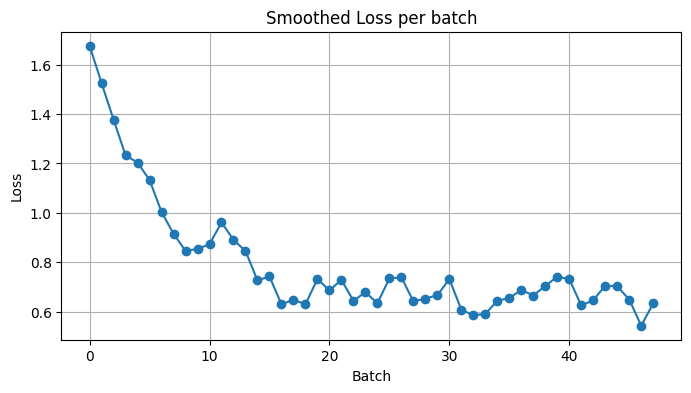

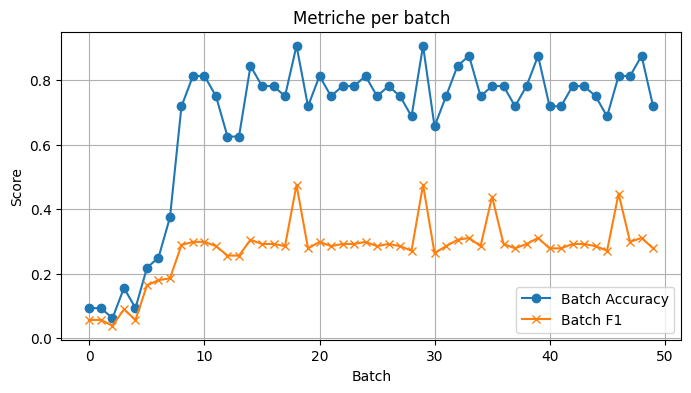

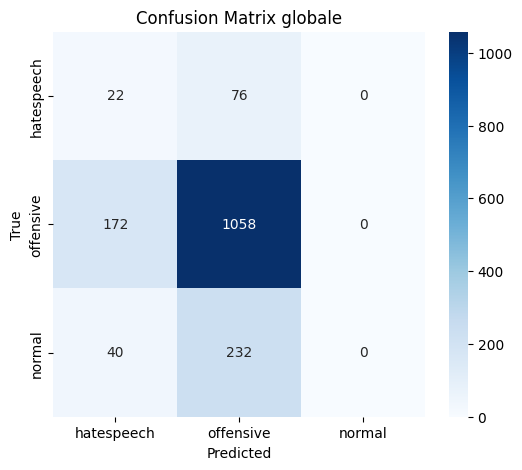

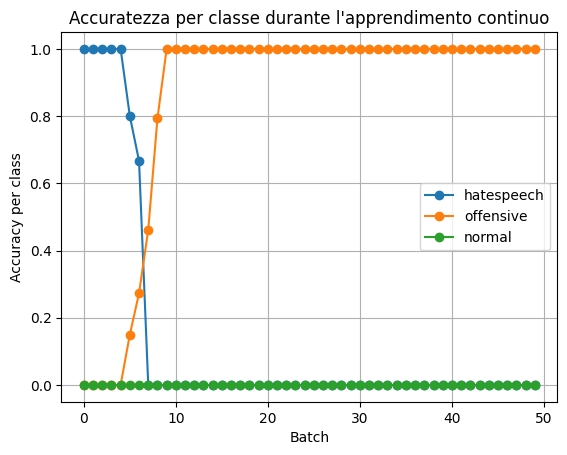

In [7]:
import matplotlib.pyplot as plt
from models.trainer import ContinualTrainer
from strategy.replay import ReplayStrategy
from utils.metrics import compute_accuracy, compute_f1
from utils.plot_utils import plot_loss, plot_batch_metrics, plot_conf_matrix, plot_classwise_accuracy, plot_prediction_distribution

batch_size = 32

# label map
label_map = {"hatespeech": 0, "offensive": 1, "normal": 2}

# Strategy
strategy = ReplayStrategy(model=model, buffer_size=50)  # buffer piccolo per test

# Trainer
trainer = ContinualTrainer(
    model=model,
    tokenizer=tokenizer,
    device=device,
    batch_size=batch_size,
    strategy=strategy  # <-- plug and play
)

# Test stream
test_stream = full_stream[:50]  # 2 batch da 10 elementi ciascuno, solo per test

# Train
losses, preds, labels = trainer.train_continual(test_stream, log_every=1)

# Metriche globali
flat_preds = torch.cat(preds)
flat_labels = torch.cat(labels)

acc = compute_accuracy(flat_preds, flat_labels)
f1 = compute_f1(flat_preds, flat_labels)

print(f"\nAccuracy globale: {acc:.4f}, F1 globale: {f1:.4f}")

# Predizioni batch
for i, (p, l) in enumerate(zip(preds, labels)):
    print(f"\nBatch {i+1} predizioni:", p.tolist())
    print(f"Batch {i+1} etichette:", l.tolist())

plot_loss(losses)
plot_batch_metrics(preds, labels)
plot_conf_matrix(preds, labels, label_map)
plot_classwise_accuracy(preds, labels, label_map)
#plot_prediction_distribution(preds, label_map)